# EDA 2: Clasificación de Inventarios (Análisis ABC - Pareto)
 Consolidar los datasets procesados de las 19 sucursales y aplicar la Ley de Pareto para identificar los Medicamentos Clase A (aquellos que representan el 80% del volumen de ventas) y que serán el foco principal de nuestro Dashboard de control.

Se encontraron 14 archivos. Procesando...
 Datos consolidados con éxito. Total de registros: 44592


C:\Users\vicas\AppData\Local\Temp\ipykernel_20440\2234859328.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=df_top, x='producto', y='cantidad', palette='viridis')
C:\Users\vicas\AppData\Local\Temp\ipykernel_20440\2234859328.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=10)


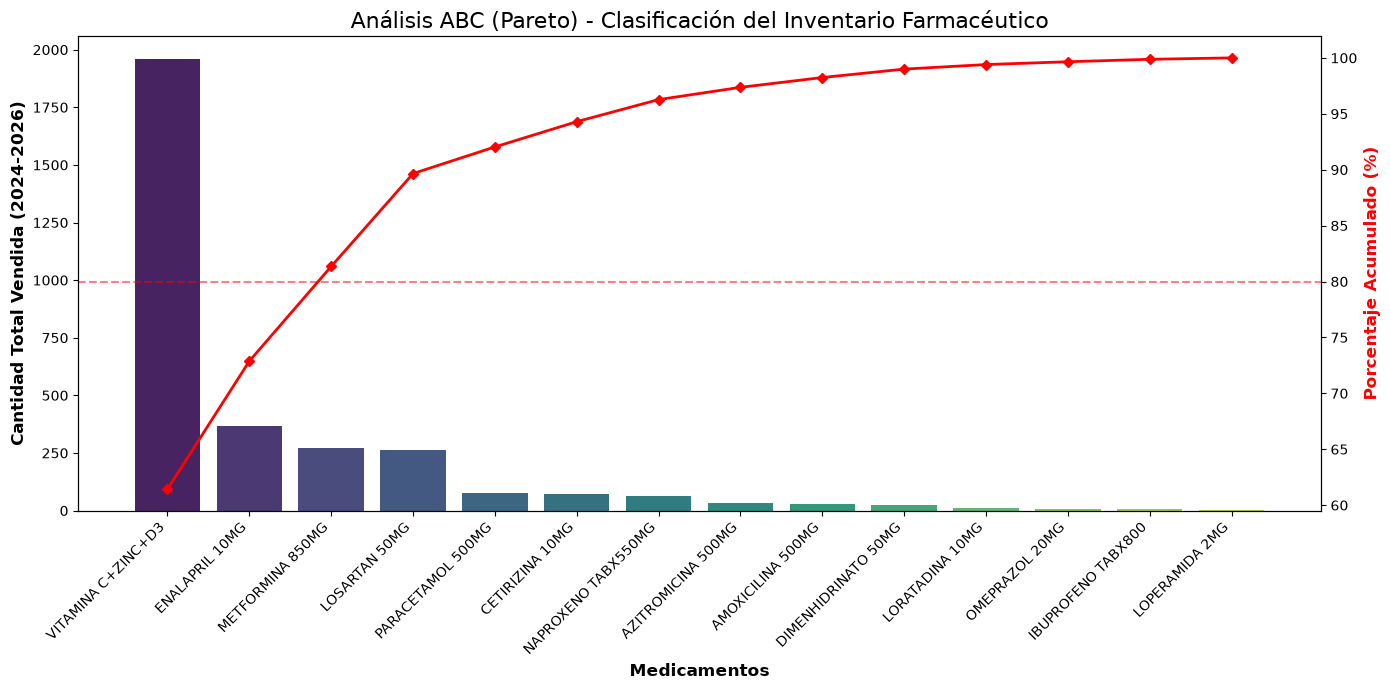


MEDICAMENTOS CLASE A (Foco del Dashboard)s
          producto  cantidad  porcentaje_acumulado
VITAMINA C+ZINC+D3    1960.0             61.442006
    ENALAPRIL 10MG     365.0             72.884013


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# ==========================================
# 1. LECTURA AUTOMÁTICA Y CONSOLIDACIÓN
# ==========================================
# Ruta donde guardaste tus CSV limpios en el paso anterior
ruta_carpeta = "../datasets/final/" 
archivos = glob.glob(os.path.join(ruta_carpeta, "*_final.csv"))

if not archivos:
    print(" No se encontraron archivos. Verifica que la ruta '../datasets/final/' sea correcta.")
else:
    print(f"Se encontraron {len(archivos)} archivos. Procesando...")

lista_dfs = []

for archivo in archivos:
    df_temp = pd.read_csv(archivo)
    
    # Extraer el nombre del producto desde el nombre del archivo
    # Ej: "AZITROMICINA 500MG(2024-2026)_final.csv" -> "AZITROMICINA 500MG"
    nombre_base = os.path.basename(archivo)
    nombre_producto = nombre_base.split('(')[0].replace('_final.csv', '').strip()
    
    # Asignar el nombre del producto a una nueva columna
    df_temp['producto'] = nombre_producto
    lista_dfs.append(df_temp)

# Unir todo en un solo DataFrame maestro
df_maestro = pd.concat(lista_dfs, ignore_index=True)
print(f" Datos consolidados con éxito. Total de registros: {len(df_maestro)}")

# ==========================================
# 2. ALGORITMO EDA: ANÁLISIS ABC (PARETO)
# ==========================================
# Agrupar por producto y sumar las cantidades
df_agrupado = df_maestro.groupby('producto')['cantidad'].sum().reset_index()
df_agrupado = df_agrupado.sort_values(by='cantidad', ascending=False)

# Calcular porcentajes para la Ley de Pareto
df_agrupado['porcentaje'] = (df_agrupado['cantidad'] / df_agrupado['cantidad'].sum()) * 100
df_agrupado['porcentaje_acumulado'] = df_agrupado['porcentaje'].cumsum()

# Función de Clasificación de Inventarios
def clasificar_abc(porcentaje):
    if porcentaje <= 80:
        return 'A (Alta Rotación)'
    elif porcentaje <= 95:
        return 'B (Rotación Media)'
    else:
        return 'C (Baja Rotación)'

df_agrupado['Categoria_ABC'] = df_agrupado['porcentaje_acumulado'].apply(clasificar_abc)

# ==========================================
# 3. VISUALIZACIÓN EJECUTIVA
# ==========================================
plt.figure(figsize=(14, 7))

# Limitar a los Top 30 para que el gráfico sea legible
top_n = min(30, len(df_agrupado))
df_top = df_agrupado.head(top_n)

# Barras de cantidades (Eje Y izquierdo)
ax1 = sns.barplot(data=df_top, x='producto', y='cantidad', palette='viridis')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax1.set_ylabel('Cantidad Total Vendida (2024-2026)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Medicamentos', fontsize=12, fontweight='bold')

# Línea de Pareto (Eje Y derecho)
ax2 = ax1.twinx()
ax2.plot(df_top['producto'], df_top['porcentaje_acumulado'], color='red', marker='D', ms=5, linewidth=2)
ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=12, fontweight='bold', color='red')
ax2.axhline(80, color='red', linestyle='--', alpha=0.5, label='Línea de Corte (80%)')

plt.title('Análisis ABC (Pareto) - Clasificación del Inventario Farmacéutico', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================
# 4. RESULTADOS: LOS MEDICAMENTOS CRÍTICOS
# ==========================================
print("\nMEDICAMENTOS CLASE A (Foco del Dashboard)s")
clase_a = df_agrupado[df_agrupado['Categoria_ABC'] == 'A (Alta Rotación)']
print(clase_a[['producto', 'cantidad', 'porcentaje_acumulado']].to_string(index=False))